# q1

In [ ]:
import graph_tool.all as gt
from graph_tool.all import Graph # again, doesnt seem to work unless i import it directly
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as spio
import json

# extracting LCC
g_full = gt.collection.ns['polblogs']
g = gt.extract_largest_component(g_full, directed=False)

# obtaining partitions
deg_corr = gt.minimize_blockmodel_dl(
    g, 
    state_args=dict(deg_corr=True), 
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

non_deg_corr = gt.minimize_blockmodel_dl(
    g, 
    state_args=dict(deg_corr=False), 
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

# PropertyMaps for visualization
dc_comms = deg_corr.get_blocks()
ndc_comms = non_deg_corr.get_blocks()

pos = gt.sfdp_layout(g)
# visualization function
def visualize(g, comms, fpath):
    gt.graph_draw(g,
                  pos=pos,
                  vertex_fill_color=comms,
                  inline=True,
                  output=fpath)
    
visualize(g, dc_comms, r'./imgs/communities_deg_corr.png')
visualize(g, ndc_comms, r'./imgs/communities_non_deg_corr.png')

Degree-corrected: 63427.543763773785
Non-degree-corrected: 83131.51079688838


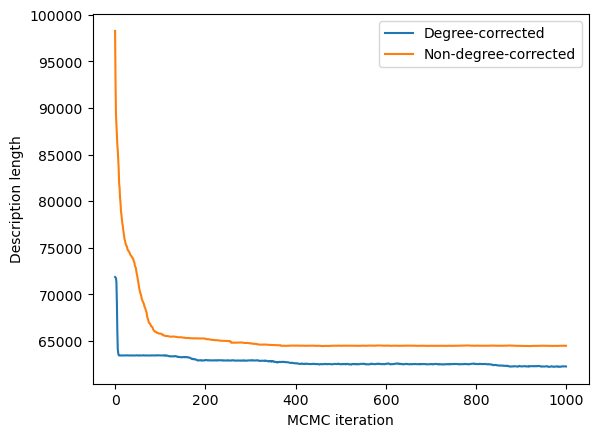

In [12]:
# desc length pt i
print(f"Degree-corrected: {deg_corr.entropy()}")
print(f"Non-degree-corrected: {non_deg_corr.entropy()}")

# init states
state_dc = gt.BlockState(g, B=2, deg_corr=True)
state_ndc = gt.BlockState(g, B=2, deg_corr=False)

def sweep(state):
    dls = []
    for i in range(1000):
        state.mcmc_sweep(niter=1)
        dls.append(state.entropy())
    return dls

dls_dc = sweep(state_dc)
dls_ndc = sweep(state_ndc)

plt.plot(dls_dc, label="Degree-corrected")
plt.plot(dls_ndc, label="Non-degree-corrected")
plt.xlabel("MCMC iteration")
plt.ylabel("Description length")
plt.legend()
plt.savefig(r'./imgs/1bii.png')

# q2

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
G = nx.karate_club_graph()
N = len(G.nodes())

X = np.zeros((N, 6)) # init empty array for later

# get 4 network attributes as dicts
degree = dict(G.degree())
clustering = nx.clustering(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

# --- create synthetic attributes ---

# defining mean and std dev (1 per attribute per club)
mean_tenure_hi = 180
std_tenure_hi = 50
mean_height_hi = 175
std_height_hi = 7

mean_tenure_o = 145
std_tenure_o = 63
mean_height_o = 181
std_height_o = 8

# collecting samples
tenure = {}
height = {}
for node, club in G.nodes(data='club'):
    if club == 'Mr. Hi':
        tenure[node] = np.random.normal(mean_tenure_hi, std_tenure_hi)
        height[node] = np.random.normal(mean_height_hi, std_height_hi)
    else:
        tenure[node] = np.random.normal(mean_tenure_o, std_tenure_o)
        height[node] = np.random.normal(mean_height_o, std_height_o)

# === Random Forest Classifier ===

# filling in feature matrix
for i in range(N):
    X[i, 0] = degree[i]
    X[i, 1] = clustering[i]
    X[i, 2] = closeness[i]
    X[i, 3] = pagerank[i]
    X[i, 4] = tenure[i]
    X[i, 5] = height[i]

# building out train/test splits
y = [G.nodes[i]['club'] for i in range(N)] # bringing in attribute for stratification/prediction
splits = []
for seed in range(50): # new seed each time
    split = {}
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    split[seed] = (X_train, X_test, y_train, y_test)
    splits.append(split)

# init lists and classifier
accuracy_scores = []
f1_scores = []
importances = []
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# fitting and recording
for seed, split in splits.items():
    X_train, X_test, y_train, y_test = split # unpacking tuple

    # fitting model and getting predictions
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    # computing accuracy and f1
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    accuracy_scores.append(acc)
    f1_scores.append(f1)

    # record importance vector, map to names
    importance = pd.Series(classifier.feature_importances_, index=X.columns)
    importances.append(importance)

    # getting confusion matrix for single split
    if seed == 1:
        cm_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

# mean and std dev for scores
mean_acc = np.mean(accuracy_scores)
mean_f1 = np.mean(f1_scores)
std_acc = np.std(accuracy_scores)
std_f1 = np.std(f1_scores)

# avg importance vector + sort in descending order
agg_importance = np.mean(importances, axis=0)
top5 = pd.Series(agg_importance, index=X.columns).sort_values(ascending=False).head(5)

# report results
print(f"Mean Accuracy: {mean_acc}\nMean F1:{mean_f1}\nStd Accuracy: {std_acc}\nStd F1: {std_f1}")
print(cm_df)
print(f"Top 5 Features by Importance: {top5}")

# === Robustness Test ===

# clean separation
print('\n=====================================\n')

# increasing noise (25%)
std_tenure_hi = std_tenure_hi * 1.25
std_height_hi = std_height_hi * 1.25
std_tenure_o = std_tenure_o * 1.25
std_height_o = std_height_o * 1.25

# --- same as before ---

# collecting samples
tenure = {}
height = {}
for node, club in G.nodes(data='club'):
    if club == 'Mr. Hi':
        tenure[node] = np.random.normal(mean_tenure_hi, std_tenure_hi)
        height[node] = np.random.normal(mean_height_hi, std_height_hi)
    else:
        tenure[node] = np.random.normal(mean_tenure_o, std_tenure_o)
        height[node] = np.random.normal(mean_height_o, std_height_o)

# filling in feature matrix
for i in range(N):
    X[i, 0] = degree[i]
    X[i, 1] = clustering[i]
    X[i, 2] = closeness[i]
    X[i, 3] = pagerank[i]
    X[i, 4] = tenure[i]
    X[i, 5] = height[i]

# building out train/test splits
y = [G.nodes[i]['club'] for i in range(N)] # bringing in attribute for stratification/prediction
splits = []
for seed in range(50): # new seed each time
    split = {}
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    split[seed] = (X_train, X_test, y_train, y_test)
    splits.append(split)

# fitting and recording
for seed, split in splits.items():
    X_train, X_test, y_train, y_test = split # unpacking tuple

    # fitting model and getting predictions
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    # computing accuracy and f1
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    accuracy_scores.append(acc)
    f1_scores.append(f1)

    # record importance vector, map to names
    importance = pd.Series(classifier.feature_importances_, index=X.columns)
    importances.append(importance)

    # getting confusion matrix for single split
    if seed == 1:
        cm_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

# mean and std dev for scores
mean_acc = np.mean(accuracy_scores)
mean_f1 = np.mean(f1_scores)
std_acc = np.std(accuracy_scores)
std_f1 = np.std(f1_scores)

# avg importance vector + sort in descending order
agg_importance = np.mean(importances, axis=0)
top5 = pd.Series(agg_importance, index=X.columns).sort_values(ascending=False).head(5)

print('Robustness Test Results (Increased Noise):')
print(f"Mean Accuracy: {mean_acc}\nMean F1:{mean_f1}\nStd Accuracy: {std_acc}\nStd F1: {std_f1}")
print(cm_df)
print(f"Top 5 Features by Importance: {top5}")